In [1]:
from google.colab import files
uploaded = files.upload()

Saving amazon_prime_titles.csv to amazon_prime_titles.csv


In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [3]:
df = pd.read_csv('/content/amazon_prime_titles.csv')

In [4]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [5]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       9668 non-null   object
 1   type          9668 non-null   object
 2   title         9668 non-null   object
 3   director      7585 non-null   object
 4   cast          8435 non-null   object
 5   country       672 non-null    object
 6   date_added    155 non-null    object
 7   release_year  9668 non-null   int64 
 8   rating        9331 non-null   object
 9   duration      9668 non-null   object
 10  listed_in     9668 non-null   object
 11  description   9668 non-null   object
dtypes: int64(1), object(11)
memory usage: 906.5+ KB


In [7]:
df.describe()

,release_year
count,9668.000000
mean,2008.341849
std,18.922482
min,1920.000000
25%,2007.000000
50%,2016.000000
75%,2019.000000
max,2021.000000


In [8]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2083
cast,1233
country,8996
date_added,9513
release_year,0
rating,337
duration,0


In [13]:
df.fillna("Unknown", inplace=True)

df.isnull().sum()

,0
type,0
release_year,0


In [14]:
df = df[['type','release_year']]

df.head()

,type,release_year
0,0,2014
1,0,2018
2,0,2017
3,0,2014
4,0,1989


In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])

df.head()

,type,release_year
0,0,2014
1,0,2018
2,0,2017
3,0,2014
4,0,1989


In [16]:
X = df[['release_year']]

y = df['type']

print(X.head())
print(y.head())

   release_year
0          2014
1          2018
2          2017
3          2014
4          1989
0    0
1    0
2    0
3    0
4    0
Name: type, dtype: int64


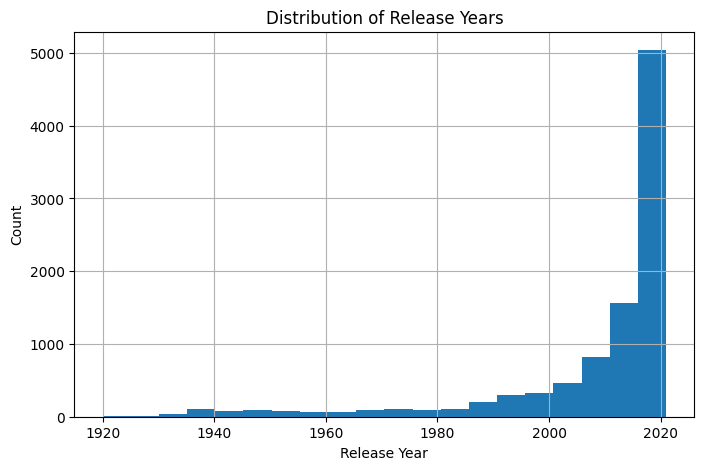

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

df['release_year'].hist(bins=20)

plt.title("Distribution of Release Years")
plt.xlabel("Release Year")
plt.ylabel("Count")

plt.show()

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 0.29903282]
 [ 0.51043252]
 [ 0.45758259]
 [ 0.29903282]
 [-1.02221525]]


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(7734, 1)
(1934, 1)


In [19]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

KNeighborsClassifier()

In [20]:
y_pred = knn.predict(X_test)

print(y_pred[:10])

[1 1 0 0 0 1 0 0 0 0]


In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 0.7419855222337125


In [22]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[1374  176]
 [ 323   61]]


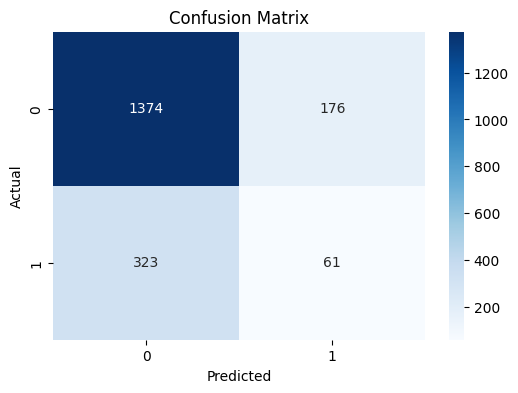

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.89      0.85      1550
           1       0.26      0.16      0.20       384

    accuracy                           0.74      1934
   macro avg       0.53      0.52      0.52      1934
weighted avg       0.70      0.74      0.72      1934



In [25]:
accuracy_scores = []

for k in range(1,21):

    model = KNeighborsClassifier(n_neighbors=k)

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    score = accuracy_score(y_test, pred)

    accuracy_scores.append(score)

print(accuracy_scores)

[0.6618407445708376, 0.7445708376421923, 0.7373319544984488, 0.7419855222337125, 0.7419855222337125, 0.7445708376421923, 0.7445708376421923, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544, 0.7750775594622544]


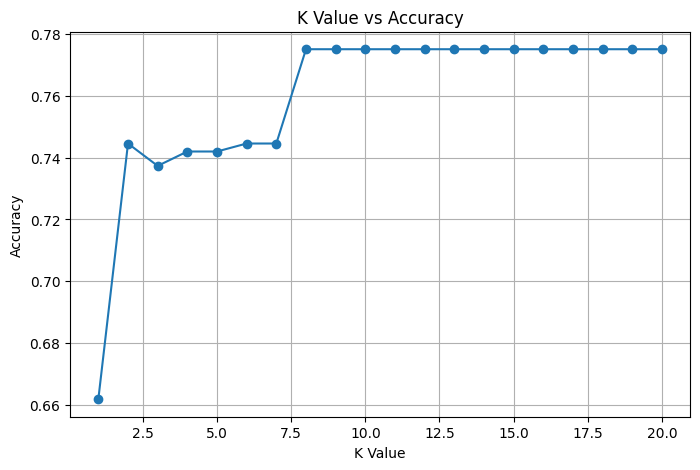

In [26]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,21),
    accuracy_scores,
    marker='o'
)

plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K Value vs Accuracy")

plt.grid()

plt.show()

In [27]:
best_k = accuracy_scores.index(max(accuracy_scores)) + 1

print("Best K =", best_k)

print("Best Accuracy =", max(accuracy_scores))

Best K = 8
Best Accuracy = 0.7750775594622544


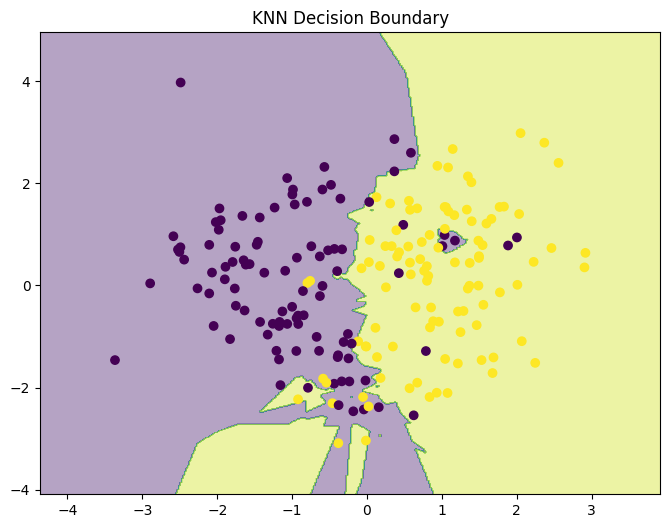

In [28]:
import numpy as np
from sklearn.datasets import make_classification

X_demo, y_demo = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=42
)

knn_demo = KNeighborsClassifier(n_neighbors=5)

knn_demo.fit(X_demo, y_demo)

h = 0.02

x_min, x_max = X_demo[:,0].min()-1, X_demo[:,0].max()+1
y_min, y_max = X_demo[:,1].min()-1, X_demo[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, h),
    np.arange(y_min, y_max, h)
)

Z = knn_demo.predict(
    np.c_[xx.ravel(), yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, Z, alpha=0.4)

plt.scatter(
    X_demo[:,0],
    X_demo[:,1],
    c=y_demo
)

plt.title("KNN Decision Boundary")

plt.show()